# Chapter 6. Generative Adversarial Network
## Instructor: Rahul Bhadani

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

# Set random seed for reproducibility
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Generator

In [2]:
class Generator(nn.Module):
    def __init__(self, latent_dim=100, height  = 28, width = 28):
        super(Generator, self).__init__()
        self.latent_dim = latent_dim
        self.height = height
        self.width = width
        
        # Build a simple feedforward network (MLP)
        # Goodfellow's original paper used fully connected layers
        self.model = nn.Sequential(
            # Input: latent_dim (100) -> Hidden 1: 256
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2),
            
            # Hidden 1 -> Hidden 2: 512
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            
            # Hidden 2 -> Hidden 3: 1024
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            
            # Hidden 3 -> Output: 784 (28*28 flattened image)  for MNIST
            nn.Linear(1024, self.width*self.height),
            nn.Tanh()  # Output in [-1, 1] to match normalized data
        )
    
    def forward(self, z):
        # z shape: [batch_size, latent_dim]
        img = self.model(z)
        img = img.view(img.size(0), 1, self.height, self.width)  # Reshape to image
        return img

Input noise shape: torch.Size([1, 100])
Output image shape: torch.Size([1, 1, 28, 28])
Output value range: [-0.116, 0.127]


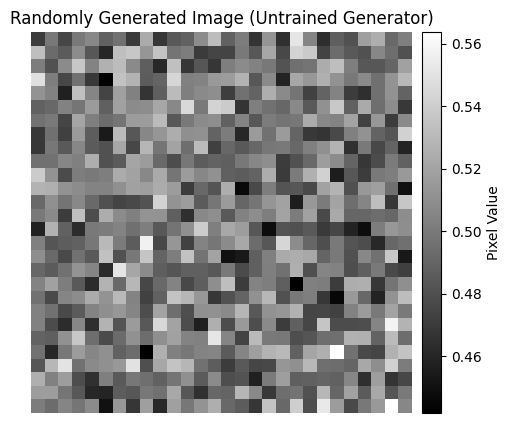

In [13]:
torch.manual_seed(42)  # For reproducibility
z = torch.randn(1, 100)  # Batch size 1, 100-

generator = Generator(latent_dim=100, height=28, width=28)
with torch.no_grad():  # No need to track gradients for inference
    generated_img = generator(z)

display_img = (generated_img.squeeze().numpy() + 1) / 2  #normalize between 0 and 1

print(f"Input noise shape: {z.shape}")
print(f"Output image shape: {generated_img.shape}")
print(f"Output value range: [{generated_img.min():.3f}, {generated_img.max():.3f}]")

from mpl_toolkits.axes_grid1 import make_axes_locatable

# Visualize the generated image
fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(display_img, cmap='gray')
ax.set_title('Randomly Generated Image (Untrained Generator)')
ax.axis('off')

# Create divider to ensure colorbar matches image height
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
cbar = plt.colorbar(im, cax=cax)
cbar.set_label('Pixel Value')

plt.tight_layout()
plt.show()

## Discriminator
Discriminator is a binary classifier: fake or real

In [15]:
class Discriminator(nn.Module):
    def __init__(self, height  = 28, width = 28):
        super(Discriminator, self).__init__()
        
        self.height = height
        self.width = width
        
        self.model = nn.Sequential(
            # Input: 784 (flattened 28*28 image) -> Hidden 1: 1024 for MNIST
            nn.Linear(self.height*self.width, 1024),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),  # Regularization
            
            # Hidden 1 -> Hidden 2: 512
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            
            # Hidden 2 -> Hidden 3: 256
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            
            # Hidden 3 -> Output: 1 (probability)
            nn.Linear(256, 1),
            nn.Sigmoid()  # Output probability [0, 1]
        )
    
    def forward(self, img):
        # img shape: [batch_size, 1, 28, 28]
        img_flat = img.view(img.size(0), -1)  # Flatten
        validity = self.model(img_flat)
        return validity


In [18]:
G = Generator(latent_dim=100).to(device)
test_noise = torch.randn(16, 100).to(device)
test_output = G(test_noise)
print(f"Generator output shape: {test_output.shape}")

D = Discriminator().to(device)
test_validity = D(test_output)
print(f"Discriminator output shape: {test_validity.shape}") 
print(test_validity)

Generator output shape: torch.Size([16, 1, 28, 28])
Discriminator output shape: torch.Size([16, 1])
tensor([[0.5146],
        [0.5113],
        [0.5156],
        [0.5212],
        [0.5174],
        [0.5201],
        [0.5189],
        [0.5173],
        [0.5197],
        [0.5159],
        [0.5197],
        [0.5186],
        [0.5176],
        [0.5194],
        [0.5183],
        [0.5204]], device='cuda:0', grad_fn=<SigmoidBackward0>)


In [19]:
# Hyperparameters (from Goodfellow's paper recommendations)
latent_dim = 100
lr = 0.0002  # Learning rate
batch_size = 64
epochs = 50

# Initialize networks
generator = Generator(latent_dim).to(device)
discriminator = Discriminator().to(device)

# Loss function: Binary Cross Entropy
adversarial_loss = nn.BCELoss()

# Optimizers (Adam as suggested in the paper)
optimizer_G = optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))

## Load Dataset

In [20]:
# Transform: normalize to [-1, 1] range (helps with tanh output)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # Normalize to [-1, 1]
])

# Download and load MNIST
train_dataset = torchvision.datasets.MNIST(
    root='./data', 
    train=True, 
    download=True, 
    transform=transform
)

train_loader = DataLoader(
    train_dataset, 
    batch_size=64, 
    shuffle=True, 
    drop_last=True  # Ensure consistent batch sizes
)

# Get a batch to check dimensions
real_batch = next(iter(train_loader))
print(f"Batch shape: {real_batch[0].shape}")  # [64, 1, 28, 28]
print(f"Label shape: {real_batch[1].shape}")  # [64]

100%|██████████| 9.91M/9.91M [00:00<00:00, 24.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 861kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 7.47MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.01MB/s]

Batch shape: torch.Size([64, 1, 28, 28])
Label shape: torch.Size([64])


## Minimax game

In [21]:
def train_gan():
    G_losses = []
    D_losses = []
    
    for epoch in range(epochs):
        for i, (real_imgs, _) in enumerate(train_loader):
            batch_size = real_imgs.size(0)
            real_imgs = real_imgs.to(device)
            
            # Create labels
            real_labels = torch.ones(batch_size, 1).to(device)
            fake_labels = torch.zeros(batch_size, 1).to(device)
            
            # ====================
            # Train Discriminator
            # ====================
            optimizer_D.zero_grad()
            
            # Loss on real images
            real_output = discriminator(real_imgs)
            d_loss_real = adversarial_loss(real_output, real_labels)
            
            # Generate fake images
            z = torch.randn(batch_size, latent_dim).to(device)
            fake_imgs = generator(z)
            
            # Loss on fake images
            fake_output = discriminator(fake_imgs.detach())  # detach() so G doesn't get gradients
            d_loss_fake = adversarial_loss(fake_output, fake_labels)
            
            # Total discriminator loss
            d_loss = (d_loss_real + d_loss_fake) / 2
            d_loss.backward()
            optimizer_D.step()
            
            # ====================
            # Train Generator
            # ====================
            optimizer_G.zero_grad()
            
            # Generate fake images again (or reuse, but fresh noise often works better)
            z = torch.randn(batch_size, latent_dim).to(device)
            fake_imgs = generator(z)
            
            # Try to fool the discriminator (want D to output 1 for fakes)
            output = discriminator(fake_imgs)
            g_loss = adversarial_loss(output, real_labels)  # Trick D with real_labels
            
            g_loss.backward()
            optimizer_G.step()
            
            # Store losses
            G_losses.append(g_loss.item())
            D_losses.append(d_loss.item())
            
            # Print progress
            if i % 100 == 0:
                print(f"Epoch [{epoch}/{epochs}] Batch [{i}/{len(train_loader)}] "
                    f"D_loss: {d_loss.item():.4f} G_loss: {g_loss.item():.4f}")
        
        # Save sample images every few epochs
        if epoch % 5 == 0:
            save_samples(generator, epoch)
    
    return G_losses, D_losses

def save_samples(generator, epoch, n_samples=16):
    """Generate and save sample images"""
    z = torch.randn(n_samples, latent_dim).to(device)
    gen_imgs = generator(z).cpu().detach()
    
    # Denormalize from [-1, 1] to [0, 1]
    gen_imgs = (gen_imgs + 1) / 2
    
    fig, axes = plt.subplots(4, 4, figsize=(6, 6))
    for i, ax in enumerate(axes.flat):
        ax.imshow(gen_imgs[i].squeeze(), cmap='gray')
        ax.axis('off')
    plt.suptitle(f'Generated Samples - Epoch {epoch}')
    plt.tight_layout()
    plt.savefig(f'gan_epoch_{epoch}.png')
    plt.close()

# Run training
print("Starting training...")
G_losses, D_losses = train_gan()

Starting training...
Epoch [0/50] Batch [0/937] D_loss: 0.6930 G_loss: 0.6628
Epoch [0/50] Batch [100/937] D_loss: 0.6706 G_loss: 0.9607
Epoch [0/50] Batch [200/937] D_loss: 0.6707 G_loss: 1.9233
Epoch [0/50] Batch [300/937] D_loss: 0.2924 G_loss: 2.4626
Epoch [0/50] Batch [400/937] D_loss: 0.1514 G_loss: 3.4756
Epoch [0/50] Batch [500/937] D_loss: 0.4270 G_loss: 1.8927
Epoch [0/50] Batch [600/937] D_loss: 0.2044 G_loss: 2.6282
Epoch [0/50] Batch [700/937] D_loss: 0.2860 G_loss: 3.2304
Epoch [0/50] Batch [800/937] D_loss: 0.3444 G_loss: 6.5506
Epoch [0/50] Batch [900/937] D_loss: 0.5769 G_loss: 7.6980
Epoch [1/50] Batch [0/937] D_loss: 0.3001 G_loss: 4.4943
Epoch [1/50] Batch [100/937] D_loss: 0.2030 G_loss: 3.2368
Epoch [1/50] Batch [200/937] D_loss: 0.2414 G_loss: 3.6151
Epoch [1/50] Batch [300/937] D_loss: 0.1625 G_loss: 3.4380
Epoch [1/50] Batch [400/937] D_loss: 0.3011 G_loss: 1.5536
Epoch [1/50] Batch [500/937] D_loss: 0.3408 G_loss: 1.1867
Epoch [1/50] Batch [600/937] D_loss: 0.

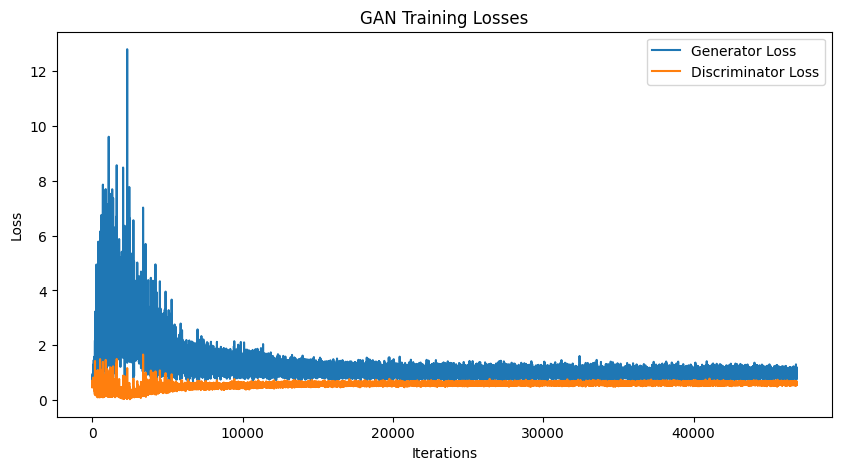

In [22]:
plt.figure(figsize=(10, 5))
plt.plot(G_losses, label='Generator Loss')
plt.plot(D_losses, label='Discriminator Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()
plt.title('GAN Training Losses')
plt.show()


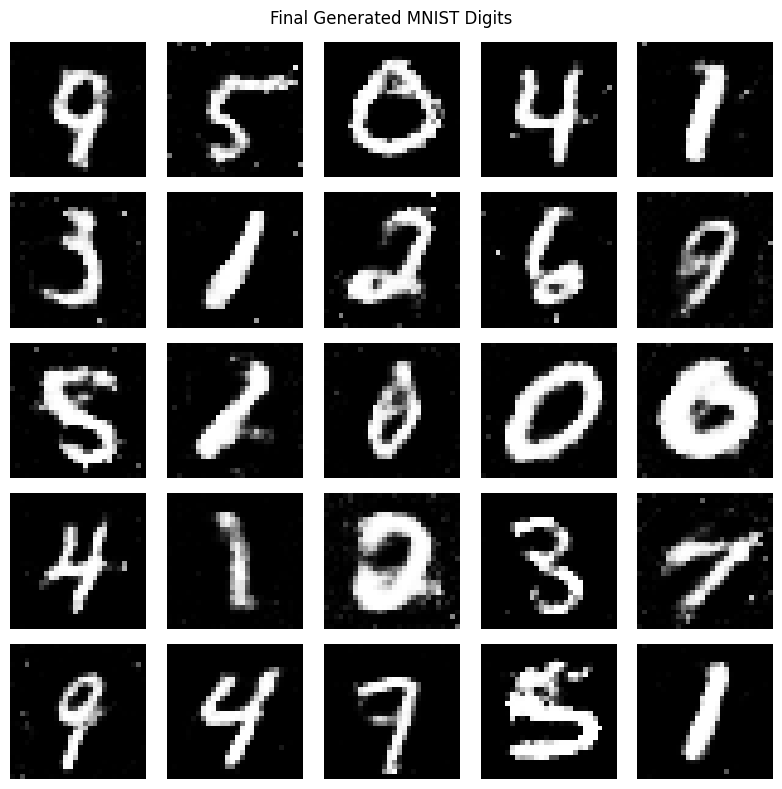

In [23]:
def generate_final_samples(n=25):
    generator.eval()
    z = torch.randn(n, latent_dim).to(device)
    with torch.no_grad():
        gen_imgs = generator(z).cpu()
    
    # Denormalize
    gen_imgs = (gen_imgs + 1) / 2
    
    fig, axes = plt.subplots(5, 5, figsize=(8, 8))
    for i, ax in enumerate(axes.flat):
        ax.imshow(gen_imgs[i].squeeze(), cmap='gray')
        ax.axis('off')
    plt.suptitle('Final Generated MNIST Digits')
    plt.tight_layout()
    plt.show()

generate_final_samples()